# Gráfico de Barras: Diferencias de CO por Tipo de Ítem con Ambos Índices

Este notebook genera **gráficos de barras agrupadas** que muestran las diferencias de Cambio de Opinión (CO) entre candidatos de izquierda y derecha, separado por tipo de ítem (progresista vs conservador) y por población ideológica.

## Diferencia con el notebook 71:
- Este notebook genera **2 gráficos** (uno por elección)
- Cada gráfico incluye **AMBAS líneas**: Índice de Progresismo e Índice de Conservadurismo

## Conceptos:

### Diferencias calculadas:
- **Dif_CO_Progresistas**: Promedio(CO_Items_Progresistas_Izq) - Promedio(CO_Items_Progresistas_Der)
- **Dif_CO_Conservadores**: Promedio(CO_Items_Conservadores_Izq) - Promedio(CO_Items_Conservadores_Der)

### Visualización:
- **Eje X**: Poblaciones ideológicas (ordenadas de izquierda a derecha)
- **Eje Y izquierdo**: Diferencias de CO
- **Eje Y derecho**: Índices de Progresismo y Conservadurismo (media por población)
- **Barras verdes**: Diferencias para ítems progresistas
- **Barras naranjas**: Diferencias para ítems conservadores
- **Línea azul**: Índice de Progresismo medio por población
- **Línea roja**: Índice de Conservadurismo medio por población
- **Barras de error**: Error estándar
- **Asteriscos**: Significancia estadística entre las dos diferencias

## Elecciones:
- Generales
- Ballotage

In [1]:
# Librerías.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats
from scipy.stats import mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo.
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('paper', font_scale=1.3)

print('✓ Librerías cargadas exitosamente')

✓ Librerías cargadas exitosamente


## 1. Cargar Datos

In [2]:
# Rutas a los archivos Excel.
Ruta_Base = os.path.join(
    os.getcwd(),
    '..',
    'Data',
    'Bases definitivas'
)
Excel_Generales = os.path.join(Ruta_Base, 'Generales.xlsx')
Excel_Ballotage = os.path.join(Ruta_Base, 'Ballotage.xlsx')

# Cargar DataFrames desde Excel.
df_Generales = pd.read_excel(Excel_Generales)
df_Ballotage = pd.read_excel(Excel_Ballotage)

print(f'✓ Datos cargados desde Excel:')
print(f'  - Generales: {len(df_Generales)} registros')
print(f'  - Ballotage: {len(df_Ballotage)} registros')

✓ Datos cargados desde Excel:
  - Generales: 2786 registros
  - Ballotage: 1254 registros


## 2. Definir Ítems y Poblaciones

In [3]:
# Ítems progresistas y conservadores.
Items_Progresistas = [5, 6, 9, 11, 16, 20, 24, 25, 27, 28]
Items_Conservadores = [3, 4, 7, 8, 10, 19, 22, 23, 29, 30]

# Poblaciones ideológicas ordenadas de izquierda a derecha.
Poblaciones_Ordenadas = [
    'Left_Wing',
    'Progressivism',
    'Centre',
    'Moderate_Right_A',
    'Moderate_Right_B',
    'Right_Wing_Libertarian'
]

# Etiquetas legibles.
Etiquetas_Poblaciones = {
    'Left_Wing': 'Left Wing',
    'Progressivism': 'Progressivism',
    'Centre': 'Centre',
    'Moderate_Right_A': 'Moderate Right A',
    'Moderate_Right_B': 'Moderate Right B',
    'Right_Wing_Libertarian': 'Right Wing Lbertarian'
}

print(f'Ítems progresistas: {len(Items_Progresistas)}')
print(f'Ítems conservadores: {len(Items_Conservadores)}')
print(f'Poblaciones: {len(Poblaciones_Ordenadas)}')

Ítems progresistas: 10
Ítems conservadores: 10
Poblaciones: 6


## 3. Calcular Diferencias de CO por Población

In [4]:
def Calcular_Diferencias_CO_Por_Poblacion(
    df,
    poblaciones,
    items_progresistas,
    items_conservadores
):

    """
    Calcula las diferencias de CO (Izq - Der) por población
    para ítems progresistas y conservadores.
    
    Retorna DataFrame con:
    - Poblacion
    - Dif_CO_Progresistas_Media
    - Dif_CO_Progresistas_SE (Error Estándar)
    - Dif_CO_Conservadores_Media
    - Dif_CO_Conservadores_SE (Error Estándar)
    - Indice_Progresismo_Media
    - Indice_Conservadurismo_Media
    - n
    - p_valor (Mann-Whitney entre las dos diferencias)
    - Significancia

    """

    resultados = []
    
    for poblacion in poblaciones:
        # Filtrar por población.
        df_pob = df[
            df['Categoria_PASO_2023'] == poblacion
        ].copy()
        
        if len(df_pob) == 0:
            continue
        
        # Para cada participante, calcular diferencia para
        # ítems progresistas.
        cols_prog_izq = [
            f'CO_Item_{i}_Izq'
            for i in items_progresistas
        ]
        cols_prog_der = [
            f'CO_Item_{i}_Der'
            for i in items_progresistas
        ]
        
        # Promedio de CO para ítems progresistas hacia izquierda.
        df_pob['Promedio_Prog_Izq'] = df_pob[
            cols_prog_izq
        ].mean(axis=1)
        
        # Promedio de CO para ítems progresistas hacia derecha.
        df_pob['Promedio_Prog_Der'] = df_pob[
            cols_prog_der
        ].mean(axis=1)
        
        # Diferencia.
        df_pob['Dif_Prog'] = (
            df_pob['Promedio_Prog_Izq']
            - df_pob['Promedio_Prog_Der']
        )
        
        # Para ítems conservadores.
        cols_cons_izq = [
            f'CO_Item_{i}_Izq'
            for i in items_conservadores
        ]
        cols_cons_der = [
            f'CO_Item_{i}_Der'
            for i in items_conservadores
        ]
        
        # Promedio de CO para ítems conservadores hacia izquierda.
        df_pob['Promedio_Cons_Izq'] = df_pob[
            cols_cons_izq
        ].mean(axis=1)
        
        # Promedio de CO para ítems conservadores hacia derecha.
        df_pob['Promedio_Cons_Der'] = df_pob[
            cols_cons_der
        ].mean(axis=1)
        
        # Diferencia.
        df_pob['Dif_Cons'] = (
            df_pob['Promedio_Cons_Izq']
            - df_pob['Promedio_Cons_Der']
        )
        
        # Estadísticas.
        dif_prog = df_pob['Dif_Prog'].dropna()
        dif_cons = df_pob['Dif_Cons'].dropna()
        
        # Calcular media y error estándar (SE = SD / sqrt(n)).
        media_prog = dif_prog.mean()
        se_prog = dif_prog.std() / np.sqrt(len(dif_prog))
        
        media_cons = dif_cons.mean()
        se_cons = dif_cons.std() / np.sqrt(len(dif_cons))
        
        # Índice de Progresismo.
        if 'Indice_Progresismo' in df_pob.columns:
            indice_prog_media = df_pob[
                'Indice_Progresismo'
            ].mean()
        else:
            indice_prog_media = np.nan
        
        # Índice de Conservadurismo.
        if 'Indice_Conservadurismo' in df_pob.columns:
            indice_cons_media = df_pob[
                'Indice_Conservadurismo'
            ].mean()
        else:
            indice_cons_media = np.nan
        
        # Test de Mann-Whitney entre las dos diferencias.
        if len(dif_prog) > 1 and len(dif_cons) > 1:
            try:
                stat, p_valor = mannwhitneyu(
                    dif_prog,
                    dif_cons,
                    alternative='two-sided'
                )
                
                # Determinar significancia.
                if p_valor < 0.001:
                    sig = '***'
                elif p_valor < 0.01:
                    sig = '**'
                elif p_valor < 0.05:
                    sig = '*'
                else:
                    sig = ''
            except:
                p_valor = np.nan
                sig = ''
        else:
            p_valor = np.nan
            sig = ''
        
        resultados.append({
            'Poblacion': poblacion,
            'Etiqueta': Etiquetas_Poblaciones[poblacion],
            'n': len(df_pob),
            'Dif_CO_Progresistas_Media': media_prog,
            'Dif_CO_Progresistas_SE': se_prog,
            'Dif_CO_Conservadores_Media': media_cons,
            'Dif_CO_Conservadores_SE': se_cons,
            'Indice_Progresismo_Media': indice_prog_media,
            'Indice_Conservadurismo_Media': indice_cons_media,
            'p_valor': p_valor,
            'Significancia': sig
        })
    
    return pd.DataFrame(resultados)


# Calcular para Generales.
print('Calculando diferencias de CO para Generales...\n')
df_Diferencias_Generales = Calcular_Diferencias_CO_Por_Poblacion(
    df_Generales,
    Poblaciones_Ordenadas,
    Items_Progresistas,
    Items_Conservadores
)

print('✓ Diferencias calculadas para Generales')

# Calcular para Ballotage.
print('\nCalculando diferencias de CO para Ballotage...\n')
df_Diferencias_Ballotage = Calcular_Diferencias_CO_Por_Poblacion(
    df_Ballotage,
    Poblaciones_Ordenadas,
    Items_Progresistas,
    Items_Conservadores
)

print('✓ Diferencias calculadas para Ballotage')

Calculando diferencias de CO para Generales...

✓ Diferencias calculadas para Generales

Calculando diferencias de CO para Ballotage...

✓ Diferencias calculadas para Ballotage


## 4. Crear Gráfico de Barras con Ambas Líneas

GENERACIÓN DE GRÁFICOS CON AMBOS ÍNDICES

1. Generales con IP e IC...

✅ Gráfico SVG guardado: Graficos_Barras\Barras_Diferencias_CO_Generales_Ambos_Indices.svg
✅ Gráfico JPG guardado: Graficos_Barras\Barras_Diferencias_CO_Generales_Ambos_Indices.jpg


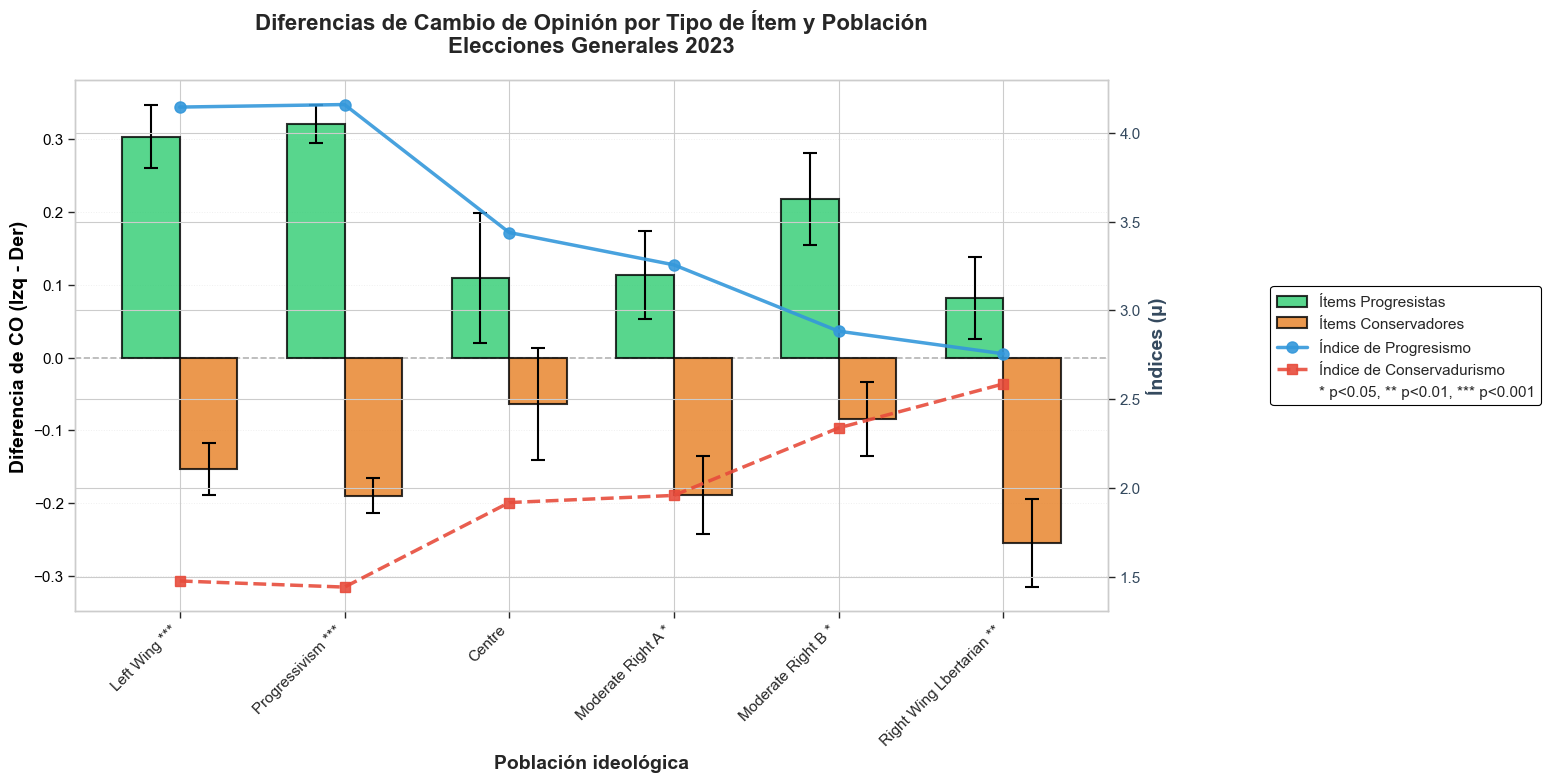


2. Ballotage con IP e IC...

✅ Gráfico SVG guardado: Graficos_Barras\Barras_Diferencias_CO_Ballotage_Ambos_Indices.svg
✅ Gráfico JPG guardado: Graficos_Barras\Barras_Diferencias_CO_Ballotage_Ambos_Indices.jpg


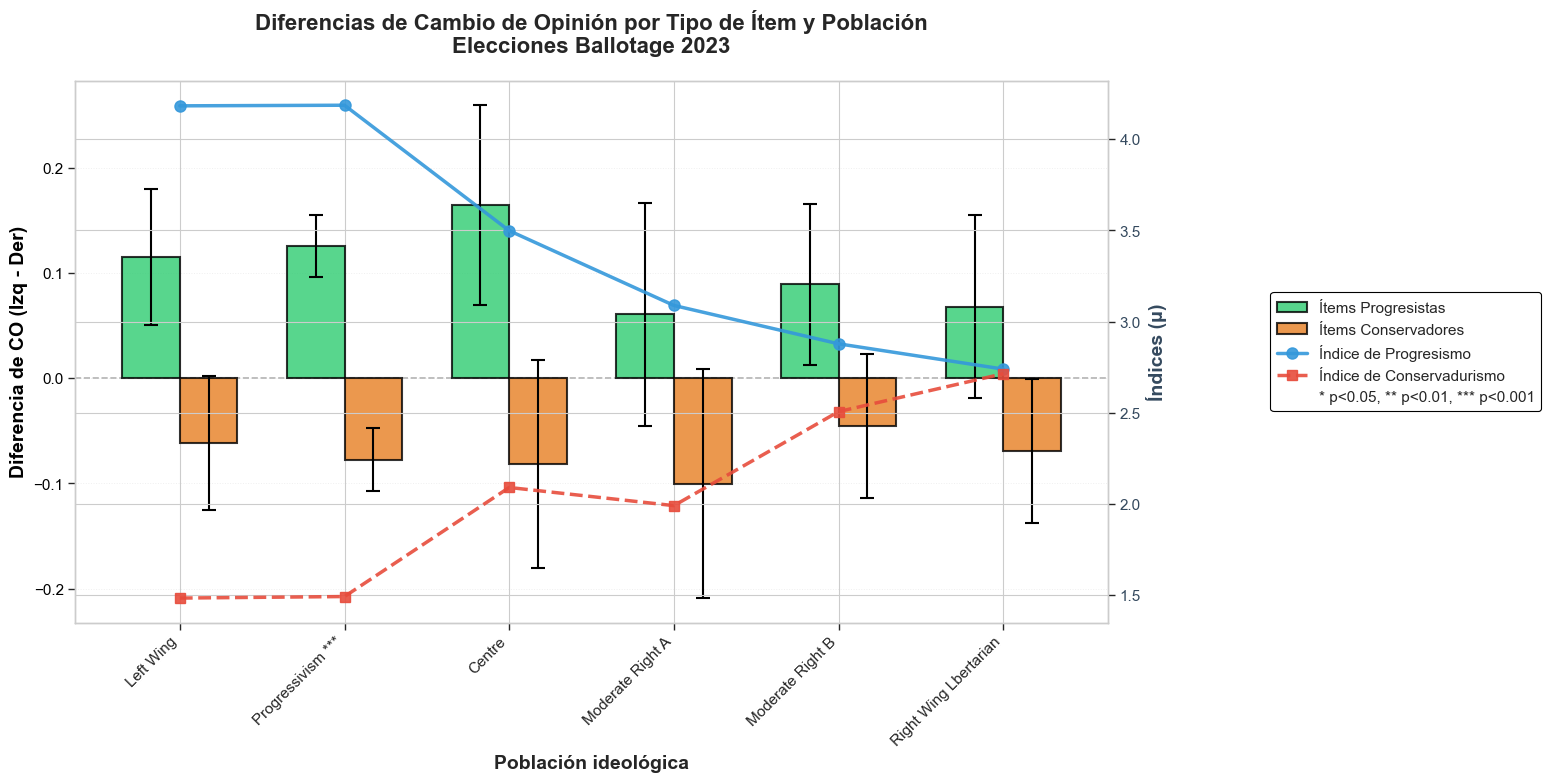


✅ Ambos gráficos generados exitosamente


In [5]:
def Crear_Grafico_Barras_Con_Ambos_Indices(
    df_datos,
    titulo,
    nombre_archivo=None,
    carpeta_destino='Graficos_Barras'
):

    """
    Crea gráfico de barras agrupadas con dos líneas superpuestas.
    
    - Barras verdes: Diferencias para ítems progresistas.
    - Barras naranjas: Diferencias para ítems conservadores.
    - Línea azul: Índice de Progresismo con eje Y secundario.
    - Línea roja: Índice de Conservadurismo con eje Y secundario.
    - Barras de error: Error estándar.
    - Asteriscos: Significancia estadística (al lado de etiquetas).

    """

    # Crear figura y ejes (más ancha para la leyenda externa).
    fig, ax1 = plt.subplots(figsize=(16, 8))
    
    # Configuración de posiciones para barras agrupadas.
    n_poblaciones = len(df_datos)
    x_pos = np.arange(n_poblaciones)
    ancho_barra = 0.35
    
    # Extraer datos.
    medias_prog = df_datos['Dif_CO_Progresistas_Media'].values
    se_prog = df_datos['Dif_CO_Progresistas_SE'].values
    
    medias_cons = df_datos['Dif_CO_Conservadores_Media'].values
    se_cons = df_datos['Dif_CO_Conservadores_SE'].values
    
    indice_prog = df_datos['Indice_Progresismo_Media'].values
    indice_cons = df_datos['Indice_Conservadurismo_Media'].values
    
    # Barras para ítems progresistas (verde).
    barras_prog = ax1.bar(
        x_pos - ancho_barra/2,
        medias_prog,
        ancho_barra,
        yerr=se_prog,
        label='Ítems Progresistas',
        color='#2ecc71',
        alpha=0.8,
        edgecolor='black',
        linewidth=1.5,
        capsize=5,
        error_kw={
            'linewidth': 2,
            'elinewidth': 1.5,
            'capthick': 1.5
        }
    )
    
    # Barras para ítems conservadores (naranja).
    barras_cons = ax1.bar(
        x_pos + ancho_barra/2,
        medias_cons,
        ancho_barra,
        yerr=se_cons,
        label='Ítems Conservadores',
        color='#e67e22',
        alpha=0.8,
        edgecolor='black',
        linewidth=1.5,
        capsize=5,
        error_kw={
            'linewidth': 2,
            'elinewidth': 1.5,
            'capthick': 1.5
        }
    )
    
    # Configurar eje Y izquierdo (Diferencias de CO).
    ax1.set_xlabel(
        'Población ideológica',
        fontsize=14,
        fontweight='bold'
    )
    ax1.set_ylabel(
        'Diferencia de CO (Izq - Der)',
        fontsize=14,
        fontweight='bold',
        color='black'
    )
    ax1.tick_params(axis='y', labelcolor='black', labelsize=11)
    ax1.tick_params(axis='x', labelsize=11)
    
    # Línea horizontal en y=0.
    ax1.axhline(
        y=0,
        color='gray',
        linestyle='--',
        linewidth=1.2,
        alpha=0.6,
        zorder=0
    )
    
    # Configurar etiquetas del eje X con asteriscos de significancia.
    etiquetas_con_sig = [
        f"{row['Etiqueta']} {row['Significancia']}"
        if row['Significancia'] else row['Etiqueta']
        for _, row in df_datos.iterrows()
    ]
    
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(
        etiquetas_con_sig,
        rotation=45,
        ha='right'
    )
    
    # Grid.
    ax1.grid(
        True,
        axis='y',
        alpha=0.3,
        linestyle=':',
        linewidth=0.7
    )
    ax1.set_axisbelow(True)
    
    # Crear eje Y secundario (derecho) para Índices.
    ax2 = ax1.twinx()
    
    # Línea de Índice de Progresismo (azul).
    linea_prog = ax2.plot(
        x_pos,
        indice_prog,
        color='#3498db',
        marker='o',
        markersize=8,
        linewidth=2.5,
        label='Índice de Progresismo',
        linestyle='-',
        alpha=0.9,
        zorder=5
    )
    
    # Línea de Índice de Conservadurismo (rojo).
    linea_cons = ax2.plot(
        x_pos,
        indice_cons,
        color='#e74c3c',
        marker='s',
        markersize=7,
        linewidth=2.5,
        label='Índice de Conservadurismo',
        linestyle='--',
        alpha=0.9,
        zorder=5
    )
    
    # Configurar eje Y derecho.
    ax2.set_ylabel(
        'Índices (μ)',
        fontsize=14,
        fontweight='bold',
        color='#34495e'
    )
    ax2.tick_params(
        axis='y',
        labelcolor='#34495e',
        labelsize=11
    )
    
    # Título.
    ax1.set_title(
        titulo,
        fontsize=16,
        fontweight='bold',
        pad=20
    )
    
    # Leyendas combinadas a la derecha del gráfico.
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    
    # Agregar explicación de asteriscos a la leyenda.
    from matplotlib.patches import Patch
    asterisco_handle = Patch(
        facecolor='none',
        edgecolor='none',
        label='* p<0.05, ** p<0.01, *** p<0.001'
    )
    
    ax1.legend(
        handles1 + handles2 + [asterisco_handle],
        labels1 + labels2 + ['* p<0.05, ** p<0.01, *** p<0.001'],
        loc='center left',
        bbox_to_anchor=(1.15, 0.5),
        ncol=1,
        fontsize=11,
        frameon=True,
        fancybox=True,
        shadow=False,
        framealpha=1.0,
        edgecolor='black',
        facecolor='white'
    )
    
    # Ajustar layout para que la leyenda no se corte.
    plt.tight_layout()

    # Guardar en SVG y JPG.
    if nombre_archivo:
        if not os.path.exists(carpeta_destino):
            os.makedirs(carpeta_destino)

        # Guardar SVG.
        ruta_svg = os.path.join(
            carpeta_destino,
            f'{nombre_archivo}.svg'
        )
        plt.savefig(
            ruta_svg,
            format='svg',
            bbox_inches='tight',
            facecolor='white',
            dpi=300
        )
        print(f'✅ Gráfico SVG guardado: {ruta_svg}')

        # Guardar JPG.
        ruta_jpg = os.path.join(
            carpeta_destino,
            f'{nombre_archivo}.jpg'
        )
        plt.savefig(
            ruta_jpg,
            format='jpg',
            bbox_inches='tight',
            facecolor='white',
            dpi=300
        )
        print(f'✅ Gráfico JPG guardado: {ruta_jpg}')

    plt.show()

    return fig, ax1, ax2


print('='*70)
print('GENERACIÓN DE GRÁFICOS CON AMBOS ÍNDICES')
print('='*70)

# Gráfico 1: Generales con ambos índices.
print('\n1. Generales con IP e IC...\n')
fig_gen, ax1_gen, ax2_gen = Crear_Grafico_Barras_Con_Ambos_Indices(
    df_Diferencias_Generales,
    titulo=(
        'Diferencias de Cambio de Opinión por '
        'Tipo de Ítem y Población\n'
        'Elecciones Generales 2023'
    ),
    nombre_archivo='Barras_Diferencias_CO_Generales_Ambos_Indices'
)

# Gráfico 2: Ballotage con ambos índices.
print('\n2. Ballotage con IP e IC...\n')
fig_bal, ax1_bal, ax2_bal = Crear_Grafico_Barras_Con_Ambos_Indices(
    df_Diferencias_Ballotage,
    titulo=(
        'Diferencias de Cambio de Opinión por '
        'Tipo de Ítem y Población\n'
        'Elecciones Ballotage 2023'
    ),
    nombre_archivo='Barras_Diferencias_CO_Ballotage_Ambos_Indices'
)

print('\n' + '='*70)
print('✅ Ambos gráficos generados exitosamente')
print('='*70)

## 5. Análisis Estadístico

In [6]:
print('='*70)
print('ANÁLISIS ESTADÍSTICO: DIFERENCIAS DE CO POR TIPO DE ÍTEM')
print('='*70)

for nombre_eleccion, df_datos in [
    ('GENERALES', df_Diferencias_Generales),
    ('BALLOTAGE', df_Diferencias_Ballotage)
]:
    print(f'\n📊 {nombre_eleccion}:')
    print('-'*70)
    
    for _, row in df_datos.iterrows():
        print(f"\n{row['Etiqueta']}:")
        print(f"  n = {row['n']}")
        print(
            f"  Dif CO Progresistas: "
            f"{row['Dif_CO_Progresistas_Media']:.4f} "
            f"± {row['Dif_CO_Progresistas_SE']:.4f} (SE)"
        )
        print(
            f"  Dif CO Conservadores: "
            f"{row['Dif_CO_Conservadores_Media']:.4f} "
            f"± {row['Dif_CO_Conservadores_SE']:.4f} (SE)"
        )
        print(
            f"  Índice Progresismo: "
            f"{row['Indice_Progresismo_Media']:.4f}"
        )
        print(
            f"  Índice Conservadurismo: "
            f"{row['Indice_Conservadurismo_Media']:.4f}"
        )
        
        if not pd.isna(row['p_valor']):
            print(f"  p-valor: {row['p_valor']:.6f}")
            if row['Significancia']:
                print(
                    f"  ✅ DIFERENCIA SIGNIFICATIVA "
                    f"({row['Significancia']})"
                )
            else:
                print(f"  ❌ No significativa")
        else:
            print(f"  p-valor: No calculado")

print('\n' + '='*70)

ANÁLISIS ESTADÍSTICO: DIFERENCIAS DE CO POR TIPO DE ÍTEM

📊 GENERALES:
----------------------------------------------------------------------

Left Wing:
  n = 425
  Dif CO Progresistas: 0.3034 ± 0.0439 (SE)
  Dif CO Conservadores: -0.1535 ± 0.0357 (SE)
  Índice Progresismo: 4.1438
  Índice Conservadurismo: 1.4779
  p-valor: 0.000000
  ✅ DIFERENCIA SIGNIFICATIVA (***)

Progressivism:
  n = 1257
  Dif CO Progresistas: 0.3201 ± 0.0258 (SE)
  Dif CO Conservadores: -0.1896 ± 0.0239 (SE)
  Índice Progresismo: 4.1580
  Índice Conservadurismo: 1.4434
  p-valor: 0.000000
  ✅ DIFERENCIA SIGNIFICATIVA (***)

Centre:
  n = 84
  Dif CO Progresistas: 0.1087 ± 0.0891 (SE)
  Dif CO Conservadores: -0.0637 ± 0.0770 (SE)
  Índice Progresismo: 3.4381
  Índice Conservadurismo: 1.9190
  p-valor: 0.973711
  ❌ No significativa

Moderate Right A:
  n = 208
  Dif CO Progresistas: 0.1131 ± 0.0603 (SE)
  Dif CO Conservadores: -0.1887 ± 0.0540 (SE)
  Índice Progresismo: 3.2562
  Índice Conservadurismo: 1.9591
  p

## 6. Guardar Resultados

In [7]:
# Guardar tablas de resultados.
Carpeta_Salida = os.path.join(
    os.getcwd(),
    '..',
    'Data',
    'Resultados_Barras'
)
if not os.path.exists(Carpeta_Salida):
    os.makedirs(Carpeta_Salida)

# Guardar Generales.
archivo_gen = os.path.join(
    Carpeta_Salida,
    'Diferencias_CO_Ambos_Indices_Generales.xlsx'
)
df_Diferencias_Generales.to_excel(archivo_gen, index=False)
print(f'✅ Resultados Generales guardados: {archivo_gen}')

# Guardar Ballotage.
archivo_bal = os.path.join(
    Carpeta_Salida,
    'Diferencias_CO_Ambos_Indices_Ballotage.xlsx'
)
df_Diferencias_Ballotage.to_excel(archivo_bal, index=False)
print(f'✅ Resultados Ballotage guardados: {archivo_bal}')

✅ Resultados Generales guardados: c:\Users\Patricio\Documents\Codigo\Python\Investigacion\Tesis\Código\..\Data\Resultados_Barras\Diferencias_CO_Ambos_Indices_Generales.xlsx
✅ Resultados Ballotage guardados: c:\Users\Patricio\Documents\Codigo\Python\Investigacion\Tesis\Código\..\Data\Resultados_Barras\Diferencias_CO_Ambos_Indices_Ballotage.xlsx


## 7. Resumen Final

In [8]:
print('='*70)
print('RESUMEN: GRÁFICO DE DIFERENCIAS DE CO CON AMBOS ÍNDICES')
print('='*70)

print('\n📊 Análisis completado:')
print(f'  - Elecciones analizadas: 2 (Generales y Ballotage)')
print(
    f'  - Poblaciones por elección: '
    f'{len(Poblaciones_Ordenadas)}'
)
print(f'  - Ítems progresistas: {len(Items_Progresistas)}')
print(f'  - Ítems conservadores: {len(Items_Conservadores)}')
print(f'  - Gráficos generados: 2 (cada uno con ambos índices)')

print('\n📁 Archivos generados:')
print('  Gráficos:')
print('    - Barras_Diferencias_CO_Generales_Ambos_Indices.svg')
print('    - Barras_Diferencias_CO_Ballotage_Ambos_Indices.svg')
print('  Datos:')
print('    - Diferencias_CO_Ambos_Indices_Generales.xlsx')
print('    - Diferencias_CO_Ambos_Indices_Ballotage.xlsx')

print('\n💡 Interpretación de los gráficos:')
print('  - Barras verdes: Diferencias para ítems progresistas')
print('  - Barras naranjas: Diferencias para ítems conservadores')
print('  - Línea azul continua (●): Índice de Progresismo medio')
print(
    '  - Línea roja discontinua (■): '
    'Índice de Conservadurismo medio'
)
print('  - Valores positivos: Mayor CO hacia izquierda')
print('  - Valores negativos: Mayor CO hacia derecha')
print(
    '  - Asteriscos junto a poblaciones: '
    'Diferencia significativa entre tipos de ítem'
)
print('    * p < 0.05')
print('    ** p < 0.01')
print('    *** p < 0.001')

# Hallazgos principales.
for nombre_eleccion, df_datos in [
    ('GENERALES', df_Diferencias_Generales),
    ('BALLOTAGE', df_Diferencias_Ballotage)
]:
    sig_count = df_datos[
        df_datos['Significancia'] != ''
    ]
    print(f'\n🎯 Hallazgos principales - {nombre_eleccion}:')
    print(
        f'  - {len(sig_count)} de {len(df_datos)} '
        f'poblaciones muestran diferencias significativas entre '
        f'tipos de ítem'
    )
    
    if len(sig_count) > 0:
        print('\n  Poblaciones con diferencias significativas:')
        for _, row in sig_count.iterrows():
            print(
                f"    {row['Significancia']:3s} "
                f"{row['Etiqueta']:25s} "
                f"(p={row['p_valor']:.4f})"
            )

print('\n' + '='*70)
print('✅ ANÁLISIS COMPLETADO')
print('='*70)

RESUMEN: GRÁFICO DE DIFERENCIAS DE CO CON AMBOS ÍNDICES

📊 Análisis completado:
  - Elecciones analizadas: 2 (Generales y Ballotage)
  - Poblaciones por elección: 6
  - Ítems progresistas: 10
  - Ítems conservadores: 10
  - Gráficos generados: 2 (cada uno con ambos índices)

📁 Archivos generados:
  Gráficos:
    - Barras_Diferencias_CO_Generales_Ambos_Indices.svg
    - Barras_Diferencias_CO_Ballotage_Ambos_Indices.svg
  Datos:
    - Diferencias_CO_Ambos_Indices_Generales.xlsx
    - Diferencias_CO_Ambos_Indices_Ballotage.xlsx

💡 Interpretación de los gráficos:
  - Barras verdes: Diferencias para ítems progresistas
  - Barras naranjas: Diferencias para ítems conservadores
  - Línea azul continua (●): Índice de Progresismo medio
  - Línea roja discontinua (■): Índice de Conservadurismo medio
  - Valores positivos: Mayor CO hacia izquierda
  - Valores negativos: Mayor CO hacia derecha
  - Asteriscos junto a poblaciones: Diferencia significativa entre tipos de ítem
    * p < 0.05
    ** p <